In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("OK")

OK


In [28]:
raw_data = pd.read_csv("./data/raw_dataset.csv")
dataset = pd.read_csv("./data/clean_dataset.csv")
print("OK")

OK


In [137]:
locs = dataset.groupby("locality")["price"].mean().to_frame().sort_values("locality")
locs = locs.drop("price", axis = 1)
locs = locs.reset_index()

In [145]:
locs.locality = locs.locality.apply(lambda x: x.lower().replace(" ", "-").replace("'", "-").replace("é", "e"))
locs.locality.unique()

<StringArray>
[              'aalbeke',                 'aalst',                'aalter',
              'aarschot',               'aarsele',             'aartrijke',
            'aartselaar',                 'achel',                 'achet',
                'achêne',
 ...
            'eben-emael',   'ecaussinnes-lalaing', 'ecaussinnes-d-enghien',
               'eghezee',               'elouges',                'enines',
               'epinois',                'eprave',                'erezee',
                'etalle']
Length: 1520, dtype: str

In [30]:
raw_data.isna().sum()

Locality                     0
Type of property             0
Subtype of property          0
Price                      513
Number of rooms            541
Living Area               1773
Terrace Area             16413
Garden Area              21076
Surface of the land      13331
Number of facades         6305
State of the building     6113
Furnished                    0
Terrace                      0
Garden                       0
Swimming pool                0
dtype: int64

In [32]:
dataset.insert(0, "index", dataset.index)
print("OK")

OK


In [33]:
dataset.head()

,index,locality,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool
0,0,Ladeuze,house,residence,90000,120,235,2,2,False,True,True,False
1,1,Charleroi,apartment,apartment,90000,49,0,2,6,False,True,False,False
2,2,Anvaing,house,residence,90000,165,1410,4,2,False,False,True,False
3,3,Dour,house,residence,90000,115,269,2,2,False,True,False,False
4,4,Élouges,house,residence,90000,113,170,2,2,False,True,True,False


In [50]:
# CLEANING
dataset = dataset[
    (dataset.living_area != 1) &
    (dataset.living_area != dataset.land_area)
]

In [51]:
dataset.sort_values("living_area")

,index,locality,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool
1138,1138,Mons,apartment,studio,156000,13,0,4,8,False,False,False,False
1136,1136,Elsene,apartment,studio,156000,13,0,4,8,False,False,False,False
408,408,Nieuwpoort,apartment,apartment,125000,15,0,2,4,True,False,False,True
41,41,Rièzes,house,residence,95000,16,1670,3,2,False,False,False,False
167,167,Sint-Andries,apartment,studio,105000,17,0,2,7,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14552,14552,Falaën,house,residence,1850000,2274,29205,4,4,False,True,True,False
14540,14540,Berloz,house,villa,1795000,2668,32475,4,4,False,True,True,False
14523,14523,Schaarbeek,house,mixed-building,1725000,2700,950,3,4,False,True,False,False
14365,14365,Kain,house,mansion,1350000,3000,14229,4,4,False,True,True,False


## Living area to Price ratio

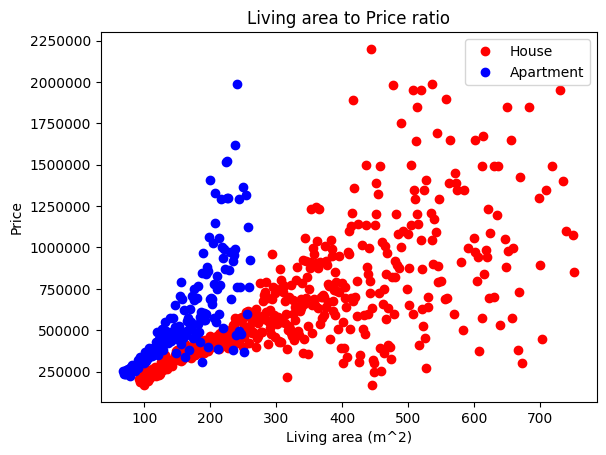

In [147]:
house_living_area = dataset[dataset.type == "house"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
apartment_living_area = dataset[dataset.type == "apartment"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
fig, ax = plt.subplots()
ax.plot(house_living_area.living_area, house_living_area.price, linestyle = "", marker = "o", color="r")
ax.plot(apartment_living_area.living_area, apartment_living_area.price, linestyle = "", marker = "o", color="b")
ax.legend(["House", "Apartment"])
ax.set_xlabel("Living area (m^2)")
ax.set_ylabel("Price")
ax.ticklabel_format(style='plain', axis='y')
ax.set_title("Living area to Price ratio")
plt.show()

In [86]:
print("Correlation between Living area and Price for houses is: ",
      house_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Living area and Price for apartments is: ",
      apartment_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Living area and Price for houses is: 0.7
Correlation between Living area and Price for apartments is: 0.74


## Price based on Subtype

Checking if **STD** is lower than **MEAN**.

In [94]:
temp = dataset.groupby("subtype")["price"].agg(["std", "mean"])
temp.iloc[:,:] /= 1000
temp

,std,mean
subtype,,
apartment,213.127332,339.361342
bungalow,118.409251,342.454545
chalet,109.047979,232.887097
cottage,319.355606,547.416049
duplex,227.636907,380.773796
ground-floor,190.489423,333.665011
loft,292.508402,494.618395
mansion,436.643038,1237.500000
master-house,433.594169,688.747464


Results: **STD** gives lower values than **MEAN**. So we can use **MEAN** to create Bar Chart for Subtypes and Prices.

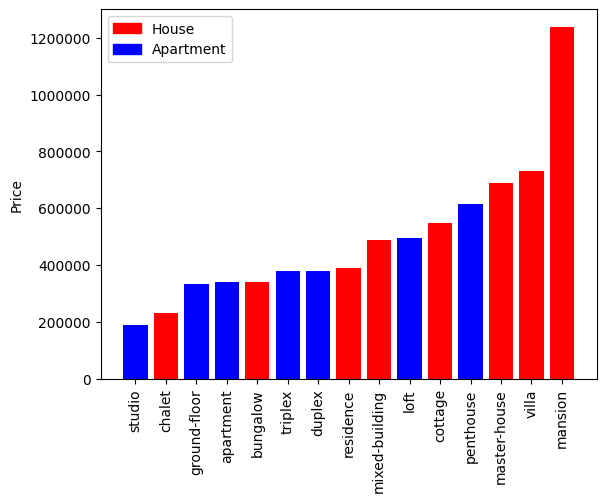

In [126]:
subtypes = dataset.groupby(["type", "subtype"])["price"].mean().to_frame().reset_index().sort_values("price")
subtypes["color"] = subtypes["type"].apply(lambda x: "r" if x == "house" else "b")
legend = [
    Patch(color="r", label = "House"),
    Patch(color="b", label = "Apartment")
]
fig, ax = plt.subplots()
ax.bar(subtypes.subtype, subtypes.price, color=subtypes.color)
ax.legend(handles = legend)
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=90)
plt.show()

In [131]:
subtypes = subtypes.iloc[:, 1:3]


,subtype,price
5,studio,1.884073e+05
8,chalet,2.328871e+05
2,ground-floor,3.336650e+05
0,apartment,3.393613e+05
7,bungalow,3.424545e+05
6,triplex,3.801674e+05
1,duplex,3.807738e+05
13,residence,3.890385e+05
12,mixed-building,4.874059e+05
3,loft,4.946184e+05
